# Lab P1: The Learning Neuron

**Goal:** Build a single neuron that learns from data — from scratch, no libraries, pure Python.

**What you'll learn:**
- The neuron equation: `y = wx + b`
- Loss functions: how to measure "how wrong"
- Gradients: which direction to move
- Learning rate: how far to step
- The training loop: repeat until learned

**Why this matters for GANs:** Every network — Generator and Discriminator — is made of neurons doing exactly this. If you understand one neuron learning, you understand all of deep learning.

**Time:** ~45 minutes

---

## Part 1: A Neuron Makes Predictions

A neuron is embarrassingly simple. It takes a number in, multiplies, adds, and gives a number out.

$$\hat{y} = w \times x + b$$

| Symbol | Name | What it does |
|---|---|---|
| `x` | Input | The data (e.g., distance in km) |
| `w` | Weight | How much `x` matters (the "volume knob") |
| `b` | Bias | A fixed shift added to every output |
| `y_hat` | Prediction | The neuron's guess |

**Example:** Predict delivery time from distance.  
True rule: `time = 2 * distance + 5` (2 min per km + 5 min prep).

In [1]:
# A neuron with known-good parameters
weight = 2
bias = 5

for distance in [1, 2, 3, 4, 5]:
    prediction = weight * distance + bias
    print(f"Distance: {distance} km  -->  Predicted time: {prediction} min")

Distance: 1 km  -->  Predicted time: 7 min
Distance: 2 km  -->  Predicted time: 9 min
Distance: 3 km  -->  Predicted time: 11 min
Distance: 4 km  -->  Predicted time: 13 min
Distance: 5 km  -->  Predicted time: 15 min


In [2]:
# Experiment: what does the weight do?
distance = 4
bias = 5

print("What happens when we change the weight:")
print("-" * 45)
for w in [0, 1, 2, 3, 5]:
    result = w * distance + bias
    print(f"  w={w}:  {w} x {distance} + {bias} = {result}")

print("\nw=0: distance has NO effect (output = bias only)")
print("Higher w: distance matters MORE")

What happens when we change the weight:
---------------------------------------------
  w=0:  0 x 4 + 5 = 5
  w=1:  1 x 4 + 5 = 9
  w=2:  2 x 4 + 5 = 13
  w=3:  3 x 4 + 5 = 17
  w=5:  5 x 4 + 5 = 25

w=0: distance has NO effect (output = bias only)
Higher w: distance matters MORE


In [3]:
# Experiment: what does the bias do?
distance = 4
weight = 2

print("What happens when we change the bias:")
print("-" * 45)
for b in [0, 3, 5, 10]:
    result = weight * distance + b
    print(f"  b={b:2d}:  {weight} x {distance} + {b} = {result}")

print("\nBias shifts ALL predictions up or down by the same amount.")

What happens when we change the bias:
---------------------------------------------
  b= 0:  2 x 4 + 0 = 8
  b= 3:  2 x 4 + 3 = 11
  b= 5:  2 x 4 + 5 = 13
  b=10:  2 x 4 + 10 = 18

Bias shifts ALL predictions up or down by the same amount.


---
## Part 2: How Wrong Is It? (Loss Function)

We just set `w=2, b=5` manually. But the neuron needs to **find** these values from data.

Step 1: measure how wrong the current prediction is. That measurement is called **loss**.

### Mean Squared Error (MSE)

$$MSE = \frac{1}{n} \sum (\hat{y} - y)^2$$

Square each error (so negatives don't cancel), then average.

In [4]:
# Our training data
distances    = [1, 2, 3]
actual_times = [7, 9, 11]

# Start with a WRONG weight
weight = 1    # should be 2
bias = 5

print("Predictions with WRONG weight (w=1):")
print("-" * 55)

squared_errors = []
for x, y in zip(distances, actual_times):
    pred = weight * x + bias
    error = pred - y
    sq_error = error ** 2
    squared_errors.append(sq_error)
    print(f"  x={x}, actual={y}, pred={pred}, error={error:+d}, squared={sq_error}")

mse = sum(squared_errors) / len(squared_errors)
print(f"\n  MSE = ({' + '.join(str(e) for e in squared_errors)}) / {len(squared_errors)} = {mse:.2f}")
print(f"\n  The neuron's loss is {mse:.2f}. Lower is better. Zero means perfect.")

Predictions with WRONG weight (w=1):
-------------------------------------------------------
  x=1, actual=7, pred=6, error=-1, squared=1
  x=2, actual=9, pred=7, error=-2, squared=4
  x=3, actual=11, pred=8, error=-3, squared=9

  MSE = (1 + 4 + 9) / 3 = 4.67

  The neuron's loss is 4.67. Lower is better. Zero means perfect.


In [5]:
# Let's make it a reusable function
def calculate_loss(weight, bias, X, Y):
    """Calculate MSE loss for given weight and bias."""
    total = 0
    for x, y in zip(X, Y):
        prediction = weight * x + bias
        total += (prediction - y) ** 2
    return total / len(X)

# Test with different weights
print("Which weight gives the lowest loss?")
print("-" * 40)
for w in [0, 1, 1.5, 2, 2.5, 3]:
    loss = calculate_loss(w, 5, distances, actual_times)
    bar = '#' * int(loss * 2)
    print(f"  w={w:3.1f}:  loss = {loss:6.2f}  {bar}")

print("\n  w=2.0 gives loss=0. That's the answer!")
print("  But the neuron can't try every weight. It needs a smarter approach.")

Which weight gives the lowest loss?
----------------------------------------
  w=0.0:  loss =  18.67  #####################################
  w=1.0:  loss =   4.67  #########
  w=1.5:  loss =   1.17  ##
  w=2.0:  loss =   0.00  
  w=2.5:  loss =   1.17  ##
  w=3.0:  loss =   4.67  #########

  w=2.0 gives loss=0. That's the answer!
  But the neuron can't try every weight. It needs a smarter approach.


### Visualize the loss landscape

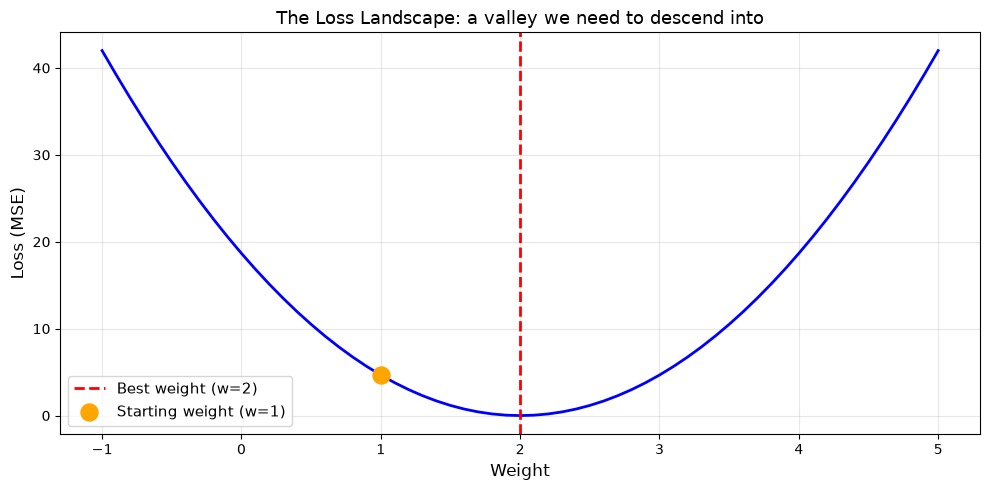

The neuron starts at w=1 (orange dot).
It needs to slide down the slope to the bottom at w=2 (red line).
But HOW does it know which direction to move?


In [6]:
import matplotlib.pyplot as plt

# Plot loss for many weights
weights = [w/10 for w in range(-10, 51)]  # -1.0 to 5.0
losses = [calculate_loss(w, 5, distances, actual_times) for w in weights]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(weights, losses, 'b-', linewidth=2)
ax.axvline(x=2.0, color='red', linestyle='--', linewidth=2, label='Best weight (w=2)')
ax.scatter([1.0], [calculate_loss(1.0, 5, distances, actual_times)],
           color='orange', s=150, zorder=5, label='Starting weight (w=1)')
ax.set_xlabel('Weight', fontsize=12)
ax.set_ylabel('Loss (MSE)', fontsize=12)
ax.set_title('The Loss Landscape: a valley we need to descend into', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("The neuron starts at w=1 (orange dot).")
print("It needs to slide down the slope to the bottom at w=2 (red line).")
print("But HOW does it know which direction to move?")

---
## Part 3: Which Direction? (The Gradient)

The **gradient** tells us the slope of the loss curve at the current weight.

| Gradient | Meaning | Action |
|---:|---|---|
| Negative | Slope goes down to the right | Increase weight |
| Positive | Slope goes down to the left | Decrease weight |
| Zero | Flat (at the bottom!) | Stop |

We estimate it by nudging the weight and seeing what happens to the loss.

In [7]:
# Estimate the gradient: nudge the weight, see how loss changes
weight = 1.0
bias = 5.0
nudge = 0.01

loss_before = calculate_loss(weight, bias, distances, actual_times)
loss_after  = calculate_loss(weight + nudge, bias, distances, actual_times)

gradient = (loss_after - loss_before) / nudge

print(f"Weight = {weight}")
print(f"Loss at w={weight:.2f}:     {loss_before:.4f}")
print(f"Loss at w={weight+nudge:.2f}:   {loss_after:.4f}")
print(f"Change in loss:         {loss_after - loss_before:.4f}")
print(f"Gradient:               {gradient:.4f}")
print(f"\nGradient is NEGATIVE --> increasing weight LOWERS the loss.")
print(f"So: MOVE RIGHT (increase w toward 2).")

Weight = 1.0
Loss at w=1.00:     4.6667
Loss at w=1.01:   4.5738
Change in loss:         -0.0929
Gradient:               -9.2867

Gradient is NEGATIVE --> increasing weight LOWERS the loss.
So: MOVE RIGHT (increase w toward 2).


Gradient at different starting weights:
-------------------------------------------------------
  w=0.5:  gradient=  -13.95  -->  increase w
  w=1.0:  gradient=   -9.29  -->  increase w
  w=1.5:  gradient=   -4.62  -->  increase w
  w=2.0:  gradient=   +0.05  -->  decrease w
  w=2.5:  gradient=   +4.71  -->  decrease w
  w=3.0:  gradient=   +9.38  -->  decrease w
  w=3.5:  gradient=  +14.05  -->  decrease w


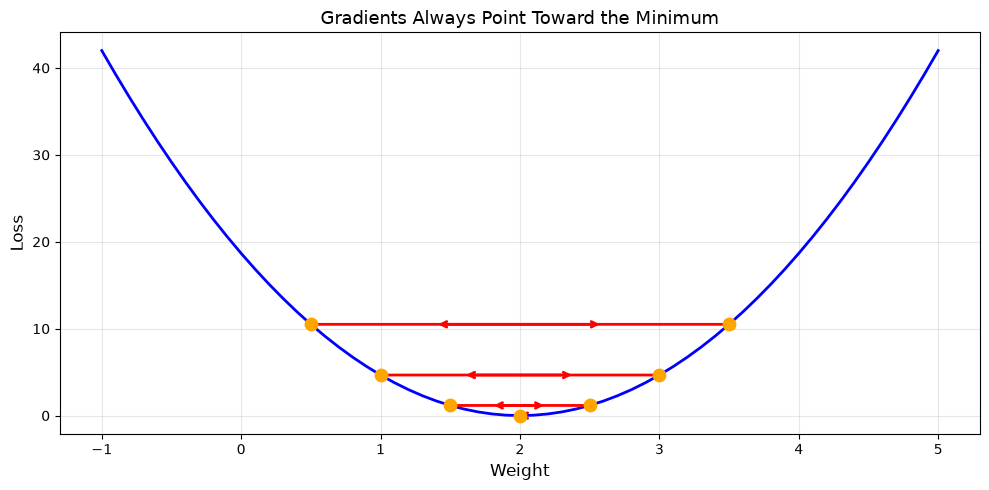


Every arrow points DOWNHILL. The gradient always leads to lower loss.


In [8]:
# Check gradient from both sides of the minimum
print("Gradient at different starting weights:")
print("-" * 55)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(weights, losses, 'b-', linewidth=2)

for w in [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5]:
    loss_here = calculate_loss(w, bias, distances, actual_times)
    grad = (calculate_loss(w + nudge, bias, distances, actual_times) - loss_here) / nudge
    direction = "increase w" if grad < 0 else "decrease w" if grad > 0 else "stay"
    print(f"  w={w:.1f}:  gradient={grad:+8.2f}  -->  {direction}")

    # Draw gradient arrow on the plot
    arrow_scale = 0.15
    ax.annotate('', xy=(w - grad * arrow_scale, loss_here),
                xytext=(w, loss_here),
                arrowprops=dict(arrowstyle='->', color='red', lw=2))
    ax.scatter([w], [loss_here], color='orange', s=80, zorder=5)

ax.set_xlabel('Weight', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Gradients Always Point Toward the Minimum', fontsize=13)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nEvery arrow points DOWNHILL. The gradient always leads to lower loss.")

---
## Part 4: How Far to Move? (Learning Rate)

The gradient tells us **direction**. The **learning rate** controls how big a step we take.

$$w_{new} = w_{old} - \text{learning\_rate} \times \text{gradient}$$

Why subtract? The gradient points UPHILL (toward higher loss). We want to go DOWNHILL.

In [9]:
# One learning step
weight = 1.0
bias = 5.0
learning_rate = 0.1
nudge = 0.001

# Calculate gradient
loss_before = calculate_loss(weight, bias, distances, actual_times)
gradient = (calculate_loss(weight + nudge, bias, distances, actual_times) - loss_before) / nudge

# Update weight
new_weight = weight - learning_rate * gradient
loss_after = calculate_loss(new_weight, bias, distances, actual_times)

print("ONE LEARNING STEP:")
print(f"  Old weight:   {weight:.4f}")
print(f"  Gradient:     {gradient:.4f}")
print(f"  Update:       {weight:.4f} - {learning_rate} x {gradient:.4f} = {new_weight:.4f}")
print(f"  New weight:   {new_weight:.4f}")
print(f"  Loss:         {loss_before:.4f}  -->  {loss_after:.4f}")
print(f"\n  Weight moved from {weight} toward 2.0. Loss dropped!")

ONE LEARNING STEP:
  Old weight:   1.0000
  Gradient:     -9.3287
  Update:       1.0000 - 0.1 x -9.3287 = 1.9329
  New weight:   1.9329
  Loss:         4.6667  -->  0.0210

  Weight moved from 1.0 toward 2.0. Loss dropped!


In [10]:
# What happens with different learning rates?
print("Effect of learning rate (one step from w=1.0):")
print("=" * 60)

loss_at_1 = calculate_loss(1.0, bias, distances, actual_times)
grad_at_1 = (calculate_loss(1.0 + nudge, bias, distances, actual_times) - loss_at_1) / nudge

results = {}
for lr in [0.001, 0.01, 0.05, 0.1, 0.2, 0.3]:
    new_w = 1.0 - lr * grad_at_1
    new_loss = calculate_loss(new_w, bias, distances, actual_times)
    status = "WORSE!" if new_loss > loss_at_1 else "better"
    results[lr] = (new_w, new_loss)
    print(f"  lr={lr:.3f}:  new_w={new_w:+7.4f}  loss={new_loss:8.4f}  {status}")

print(f"\n  Too small (0.001): barely moved.")
print(f"  Too large (0.3):   overshot the minimum, loss got WORSE!")
print(f"  Sweet spot: 0.05-0.10")

Effect of learning rate (one step from w=1.0):
  lr=0.001:  new_w=+1.0093  loss=  4.5800  better
  lr=0.010:  new_w=+1.0933  loss=  3.8366  better
  lr=0.050:  new_w=+1.4664  loss=  1.3286  better
  lr=0.100:  new_w=+1.9329  loss=  0.0210  better
  lr=0.200:  new_w=+2.8657  loss=  3.4976  better
  lr=0.300:  new_w=+3.7986  loss= 15.0965  WORSE!

  Too small (0.001): barely moved.
  Too large (0.3):   overshot the minimum, loss got WORSE!
  Sweet spot: 0.05-0.10


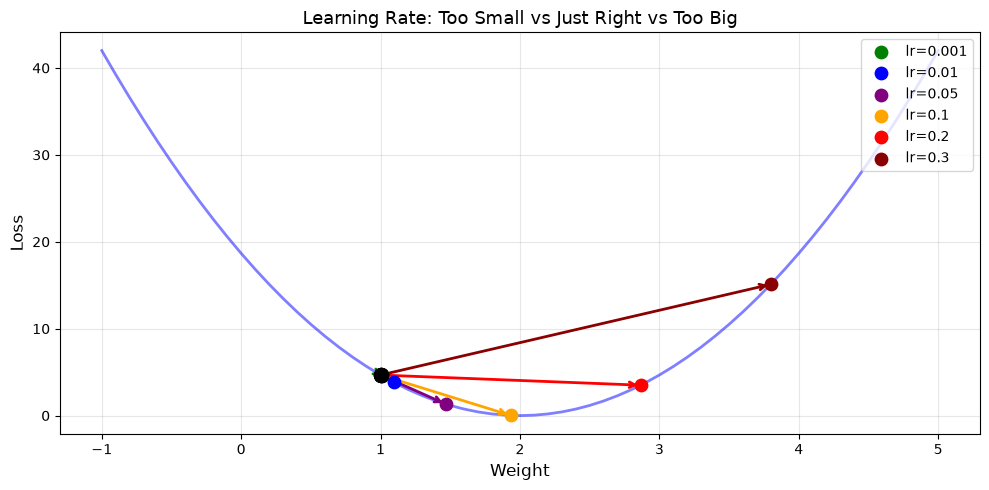

In [11]:
# Visualize: where each learning rate lands
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(weights, losses, 'b-', linewidth=2, alpha=0.5)

colors = ['green', 'blue', 'purple', 'orange', 'red', 'darkred']
for (lr, (new_w, new_loss)), color in zip(results.items(), colors):
    ax.scatter([1.0], [loss_at_1], color='black', s=100, zorder=5)
    ax.annotate('', xy=(new_w, new_loss), xytext=(1.0, loss_at_1),
                arrowprops=dict(arrowstyle='->', color=color, lw=2))
    ax.scatter([new_w], [new_loss], color=color, s=80, zorder=5,
              label=f'lr={lr}')

ax.set_xlabel('Weight', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Learning Rate: Too Small vs Just Right vs Too Big', fontsize=13)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Part 5: The Training Loop (Repeat Until Learned)

One step isn't enough. We repeat:

```
1. Calculate loss
2. Calculate gradient
3. Update weight: w = w - lr * gradient
4. Go back to step 1
```

This is the **training loop** — the same pattern used in EVERY neural network, including GANs.

In [12]:
# The complete training loop
weight = 1.0
bias = 5.0
learning_rate = 0.1
nudge = 0.001

weight_history = [weight]
loss_history = [calculate_loss(weight, bias, distances, actual_times)]

print("TRAINING A NEURON")
print("=" * 60)
print(f"{'Step':>4}  {'Weight':>8}  {'Loss':>10}  {'Gradient':>10}")
print("-" * 60)
print(f"   0  {weight:8.4f}  {loss_history[0]:10.6f}        ---")

for step in range(1, 21):
    # 1. Current loss
    current_loss = calculate_loss(weight, bias, distances, actual_times)

    # 2. Estimate gradient
    gradient = (calculate_loss(weight + nudge, bias, distances, actual_times)
                - current_loss) / nudge

    # 3. Update weight
    weight = weight - learning_rate * gradient

    # Track
    new_loss = calculate_loss(weight, bias, distances, actual_times)
    weight_history.append(weight)
    loss_history.append(new_loss)

    if step <= 10 or step == 20:
        print(f"  {step:2d}  {weight:8.4f}  {new_loss:10.6f}  {gradient:+10.4f}")
    elif step == 11:
        print(f"  ...")

print(f"\n  Final weight: {weight:.4f} (target: 2.0)")
print(f"  Final loss:   {loss_history[-1]:.8f}")
print(f"\n  The neuron LEARNED w=2 on its own!")

TRAINING A NEURON
Step    Weight        Loss    Gradient
------------------------------------------------------------
   0    1.0000    4.666667        ---
   1    1.9329    0.021032     -9.3287
   2    1.9951    0.000114     -0.6219
   3    1.9992    0.000003     -0.0415
   4    1.9995    0.000001     -0.0028
   5    1.9995    0.000001     -0.0002
   6    1.9995    0.000001     -0.0000
   7    1.9995    0.000001     -0.0000
   8    1.9995    0.000001     -0.0000
   9    1.9995    0.000001     -0.0000
  10    1.9995    0.000001     -0.0000
  ...
  20    1.9995    0.000001     +0.0000

  Final weight: 1.9995 (target: 2.0)
  Final loss:   0.00000117

  The neuron LEARNED w=2 on its own!


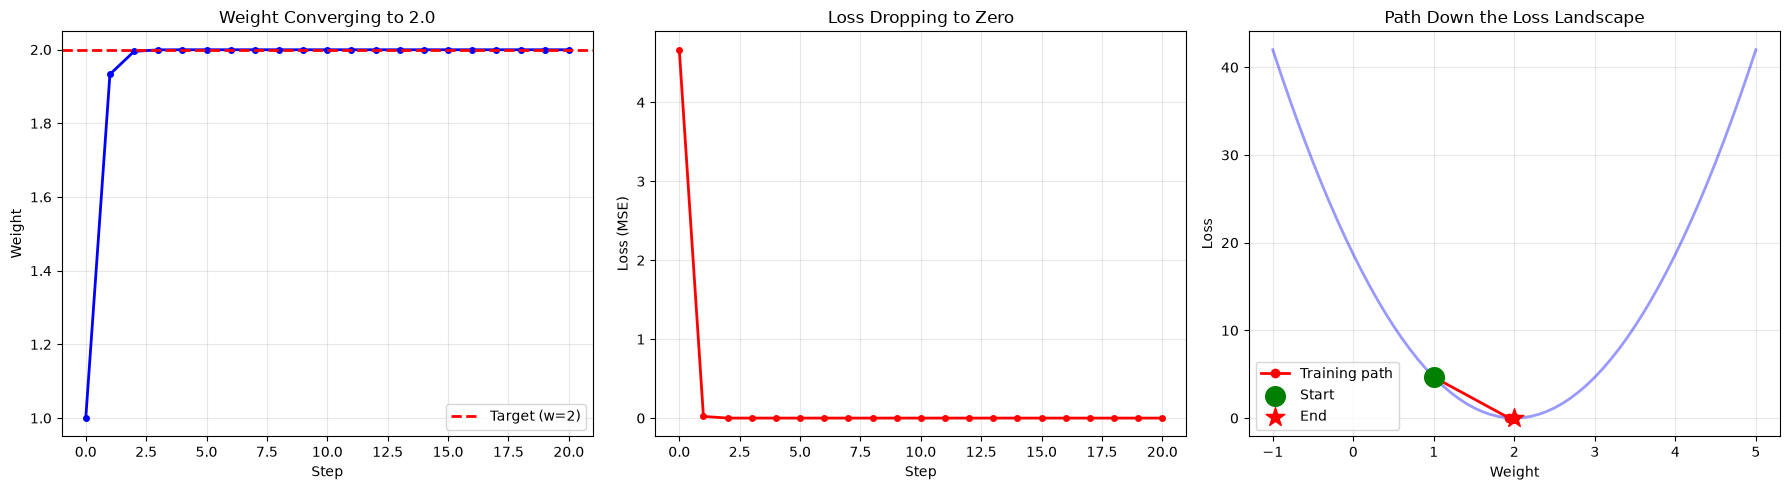

In [13]:
# Visualize the journey
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Weight over time
axes[0].plot(weight_history, 'b-o', markersize=4, linewidth=2)
axes[0].axhline(y=2.0, color='red', linestyle='--', linewidth=2, label='Target (w=2)')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Weight')
axes[0].set_title('Weight Converging to 2.0')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Loss over time
axes[1].plot(loss_history, 'r-o', markersize=4, linewidth=2)
axes[1].set_xlabel('Step')
axes[1].set_ylabel('Loss (MSE)')
axes[1].set_title('Loss Dropping to Zero')
axes[1].grid(True, alpha=0.3)

# Plot 3: Path on the loss landscape
w_range = [w/10 for w in range(-10, 51)]
l_range = [calculate_loss(w, 5, distances, actual_times) for w in w_range]
axes[2].plot(w_range, l_range, 'b-', linewidth=2, alpha=0.4)
axes[2].plot(weight_history, loss_history, 'ro-', markersize=6, linewidth=2,
             label='Training path')
axes[2].scatter([weight_history[0]], [loss_history[0]], color='green', s=200,
               zorder=5, label='Start')
axes[2].scatter([weight_history[-1]], [loss_history[-1]], color='red', s=200,
               zorder=5, marker='*', label='End')
axes[2].set_xlabel('Weight')
axes[2].set_ylabel('Loss')
axes[2].set_title('Path Down the Loss Landscape')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Part 6: Test the Learned Neuron

In [14]:
# Test on training data AND unseen data
print("Predictions with learned weight:")
print("=" * 50)

# Training data
print("Training data (seen during training):")
for x, y in zip(distances, actual_times):
    pred = weight * x + bias
    print(f"  x={x}:  actual={y}, predicted={pred:.2f}")

# Unseen data!
print("\nNew data (NEVER seen during training):")
for x in [4, 5, 10]:
    pred = weight * x + bias
    true = 2 * x + 5
    print(f"  x={x}:  true={true}, predicted={pred:.2f}")

print("\nThe neuron generalizes! It can predict for distances it never trained on.")

Predictions with learned weight:
Training data (seen during training):
  x=1:  actual=7, predicted=7.00
  x=2:  actual=9, predicted=9.00
  x=3:  actual=11, predicted=11.00

New data (NEVER seen during training):
  x=4:  true=13, predicted=13.00
  x=5:  true=15, predicted=15.00
  x=10:  true=25, predicted=24.99

The neuron generalizes! It can predict for distances it never trained on.


---
## Part 7: Experiments

### Experiment 1: Learning rate comparison over 20 steps

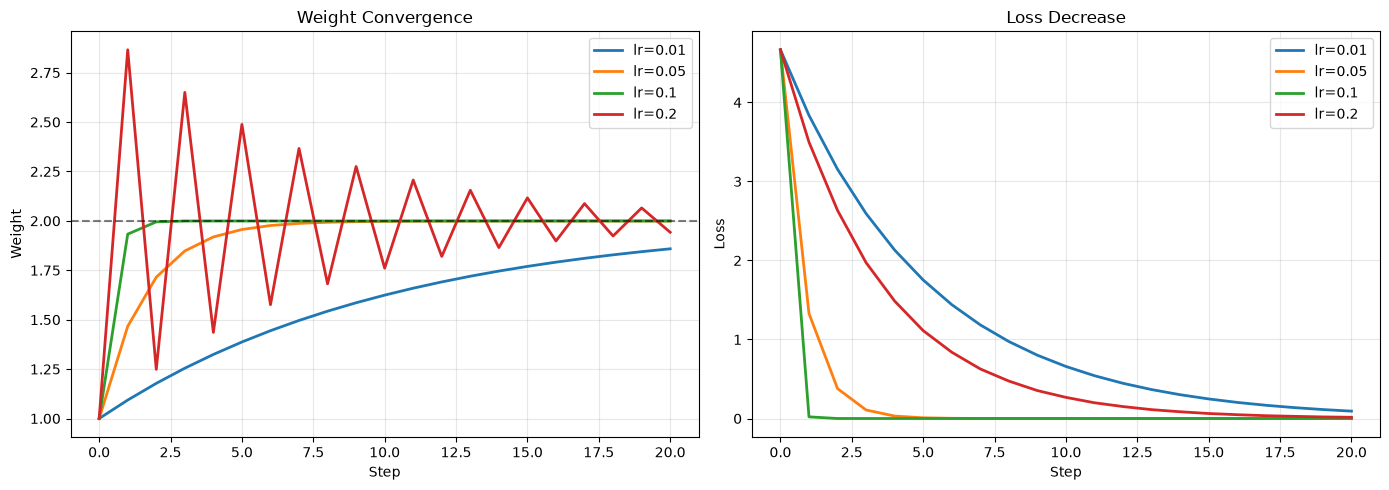

lr=0.01: safe but slow
lr=0.1:  fast and stable
lr=0.2:  might overshoot


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for lr in [0.01, 0.05, 0.1, 0.2]:
    w = 1.0
    w_hist = [w]
    l_hist = [calculate_loss(w, 5, distances, actual_times)]

    for step in range(20):
        loss = calculate_loss(w, 5, distances, actual_times)
        grad = (calculate_loss(w + 0.001, 5, distances, actual_times) - loss) / 0.001
        w = w - lr * grad
        w_hist.append(w)
        l_hist.append(calculate_loss(w, 5, distances, actual_times))

    axes[0].plot(w_hist, label=f'lr={lr}', linewidth=2)
    axes[1].plot(l_hist, label=f'lr={lr}', linewidth=2)

axes[0].axhline(y=2.0, color='black', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Weight')
axes[0].set_title('Weight Convergence')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Step')
axes[1].set_ylabel('Loss')
axes[1].set_title('Loss Decrease')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("lr=0.01: safe but slow")
print("lr=0.1:  fast and stable")
print("lr=0.2:  might overshoot")

### Experiment 2: What happens when the learning rate is WAY too high?

In [16]:
# Divergence: lr=0.3
w = 1.0
lr = 0.3

print(f"Divergence with lr={lr}:")
print("-" * 50)
for step in range(8):
    loss = calculate_loss(w, 5, distances, actual_times)
    grad = (calculate_loss(w + 0.001, 5, distances, actual_times) - loss) / 0.001
    w = w - lr * grad
    new_loss = calculate_loss(w, 5, distances, actual_times)
    print(f"  Step {step+1}: w={w:12.2f}  loss={new_loss:15.2f}")

print(f"\n  EXPLODED! The weight bounces back and forth, getting worse each time.")
print(f"  This is called DIVERGENCE.")

Divergence with lr=0.3:
--------------------------------------------------
  Step 1: w=        3.80  loss=          15.10
  Step 2: w=       -1.24  loss=          48.95
  Step 3: w=        7.83  loss=         158.54
  Step 4: w=       -8.49  loss=         513.80
  Step 5: w=       20.89  loss=        1664.46
  Step 6: w=      -32.00  loss=        5393.31
  Step 7: w=       63.19  loss=       17473.52
  Step 8: w=     -108.15  loss=       56615.64

  EXPLODED! The weight bounces back and forth, getting worse each time.
  This is called DIVERGENCE.


### Experiment 3: Learn both weight AND bias

In [17]:
# Start with wrong weight AND wrong bias
weight = 0.5   # should be 2
bias = 1.0     # should be 5
lr = 0.01
nudge = 0.001

w_hist, b_hist, l_hist = [weight], [bias], []

for step in range(1, 201):
    loss = calculate_loss(weight, bias, distances, actual_times)
    l_hist.append(loss)

    # Gradient for weight
    grad_w = (calculate_loss(weight + nudge, bias, distances, actual_times) - loss) / nudge
    # Gradient for bias
    grad_b = (calculate_loss(weight, bias + nudge, distances, actual_times) - loss) / nudge

    weight = weight - lr * grad_w
    bias = bias - lr * grad_b

    w_hist.append(weight)
    b_hist.append(bias)

    if step in [1, 10, 50, 100, 200]:
        print(f"Step {step:3d}:  w={weight:.4f}  b={bias:.4f}  loss={loss:.6f}")

print(f"\nLearned: w={weight:.4f} (target 2.0), b={bias:.4f} (target 5.0)")

Step   1:  w=0.8000  b=1.1400  loss=50.500000
Step  10:  w=2.3588  b=1.8972  loss=7.027040
Step  50:  w=3.0833  b=2.5156  loss=0.887724
Step 100:  w=2.9670  b=2.8007  loss=0.697150
Step 200:  w=2.7597  b=3.2719  loss=0.430407

Learned: w=2.7597 (target 2.0), b=3.2719 (target 5.0)


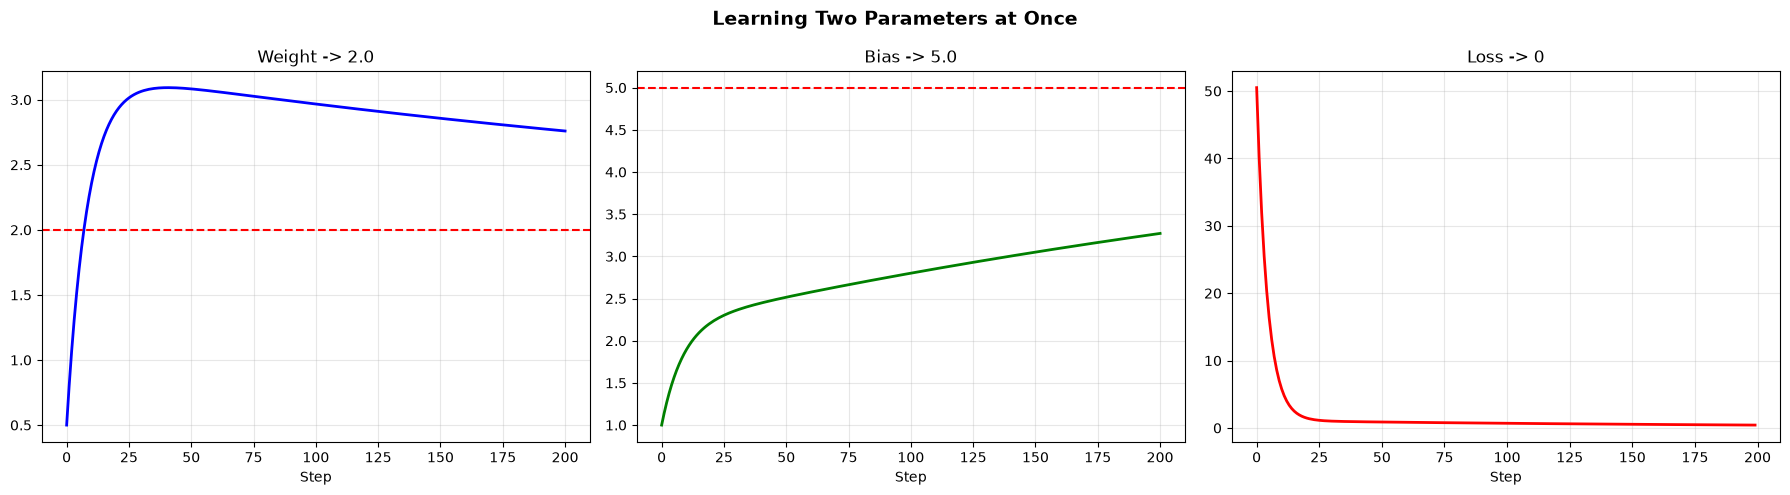

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(w_hist, 'b-', linewidth=2)
axes[0].axhline(y=2.0, color='red', linestyle='--')
axes[0].set_title('Weight -> 2.0')
axes[0].set_xlabel('Step')
axes[0].grid(True, alpha=0.3)

axes[1].plot(b_hist, 'g-', linewidth=2)
axes[1].axhline(y=5.0, color='red', linestyle='--')
axes[1].set_title('Bias -> 5.0')
axes[1].set_xlabel('Step')
axes[1].grid(True, alpha=0.3)

axes[2].plot(l_hist, 'r-', linewidth=2)
axes[2].set_title('Loss -> 0')
axes[2].set_xlabel('Step')
axes[2].grid(True, alpha=0.3)

plt.suptitle('Learning Two Parameters at Once', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Part 8: Summary

| Concept | What it does | Formula |
|---|---|---|
| **Neuron** | Makes predictions | `y = wx + b` |
| **Loss (MSE)** | Measures error | `mean of (pred - actual)^2` |
| **Gradient** | Direction of steepest ascent | `(loss_after - loss_before) / nudge` |
| **Learning rate** | Step size | Controls how far we move |
| **Update rule** | One learning step | `w = w - lr * gradient` |
| **Training loop** | Repeat until learned | loss -> gradient -> update -> repeat |

**The key insight:** The neuron never "sees" the answer. It discovers w=2 and b=5 purely by following the gradient downhill. This is how ALL neural networks learn.

**Next lab:** One neuron can only fit straight lines. What about curved data? We need hidden layers and activation functions.